# Phase 1: Download data

In [ ]:
from stackapi import StackAPI
import pandas as pd
import time
import os

def fetch_cs_data(target_count=5000000, csv_path = 'data/cs/cs_raw.csv'):
    key = 'rl_oEDaHHZDZpBQYbecJxwqdr3Ss'
    SITE = StackAPI('cs', key=key)
    SITE.page_size = 100
    
    data = []
    page = 1
    total_fetched = 0
    
    os.makedirs('data', exist_ok=True)
    
    
    while total_fetched < target_count:
        try:
            questions = SITE.fetch('questions', 
                                  page=page, 
                                  min=1, 
                                  sort='votes', 
                                  filter='withbody')
            
            if 'items' not in questions or not questions['items']:
                break
                
            batch_data = []
            for item in questions['items']:
                batch_data.append({
                    'title': item.get('title'),
                    'body': item.get('body'),
                    'tags': '|'.join(item.get('tags', []))
                })
            
            data.extend(batch_data)
            total_fetched += len(batch_data)
            print(f"Progress: {total_fetched}/{target_count} (Page {page})")
            
            if page % 100 == 0:
                df_batch = pd.DataFrame(data)
                df_batch.to_csv(csv_path, index=False, mode='a', header=not os.path.exists(csv_path))
                data = []
                
            page += 1
            time.sleep(0.1)
            
        except Exception as e:
            print(f"Stop at page {page}: {e}")
            break

    if data:
        pd.DataFrame(data).to_csv(csv_path, index=False, mode='a', header=not os.path.exists(csv_path))
        return csv_path

#path = fetch_cs_data(75000)

# Phase 2: EDA

## I. Data Exploring

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
df = pd.read_csv('data/cs/cs_raw.csv')
print("--- Dataset Info ---")
print(df.info())
print("--- Sample Data ---")
sample = df.head(5)
print(sample)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77500 entries, 0 to 77499
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   77500 non-null  object
 1   body    77500 non-null  object
 2   tags    77500 non-null  object
dtypes: object(3)
memory usage: 1.8+ MB
None
--- Sample Data ---
                                               title  \
0  Why is quicksort better than other sorting alg...   
1  What is the definition of P, NP, NP-complete a...   
2  Why is writing down mathematical proofs more f...   
3  Is there a system behind the magic of algorith...   
4  How can a language whose compiler is written i...   

                                                body  \
0  <p>In a standard algorithms course we are taug...   
1  <p>I'm in a course about <em>computing</em> an...   
2  <p>I have noticed that I find it far easier to...   
3  <p>There are lots of questions about how to an...   
4  <p>Tak

### 1. Frequency and distribution

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

def eda(df, out_dir='result/cs'):
    os.makedirs(out_dir, exist_ok=True)
    
    df['t_len'] = df['title'].apply(lambda x: len(str(x).split()))
    df['b_len'] = df['body'].apply(lambda x: len(str(x).split()))
    
    if not isinstance(df['tags'].iloc[0], list):
        df['tags'] = df['tags'].str.split('|')
    tags = []
    df['tags'].apply(lambda x: tags.extend(x) if isinstance(x, list) else None)  
    df['tags_count'] = df['tags'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    
    print("--- Stats ---")
    print(df[['t_len', 'b_len', 'tags_count']].describe())

    c = Counter(tags)
    
    print(f"\nUnique Tags: {len(c)}")
    print("Top 10:", c.most_common(10))
    
    plt.figure(figsize=(10, 5))
    sns.histplot(df['b_len'], bins=50, kde=True)
    plt.title('Body Length')
    plt.savefig(f'{out_dir}/b_dist.png')
    plt.show()
    plt.close()
    
    top_df = pd.DataFrame(c.most_common(20), columns=['tag', 'count'])
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_df, x='count', y='tag')
    plt.title('Top 20 Tags')
    plt.savefig(f'{out_dir}/t_dist.png')
    plt.show()
    plt.close()

    plt.figure(figsize=(10, 5))
    sns.histplot(df['tags_count'], bins=50, kde=True)
    plt.title('Body Length')
    plt.savefig(f'{out_dir}/b_dist.png')
    plt.show()
    plt.close()

--- Stats ---
              t_len         b_len    tags_count
count  77500.000000  77500.000000  77500.000000
mean       9.202826    166.186000      2.766103
std        4.064276    140.628033      1.117592
min        1.000000      8.000000      1.000000
25%        6.000000     77.000000      2.000000
50%        9.000000    128.000000      3.000000
75%       11.000000    210.000000      4.000000
max       34.000000   2039.000000      5.000000

Unique Tags: 638
Top 10: [('algorithms', 19384), ('complexity-theory', 10558), ('graphs', 8752), ('formal-languages', 5008), ('computability', 3915), ('time-complexity', 3901), ('data-structures', 3883), ('turing-machines', 3615), ('optimization', 3251), ('algorithm-analysis', 3182)]


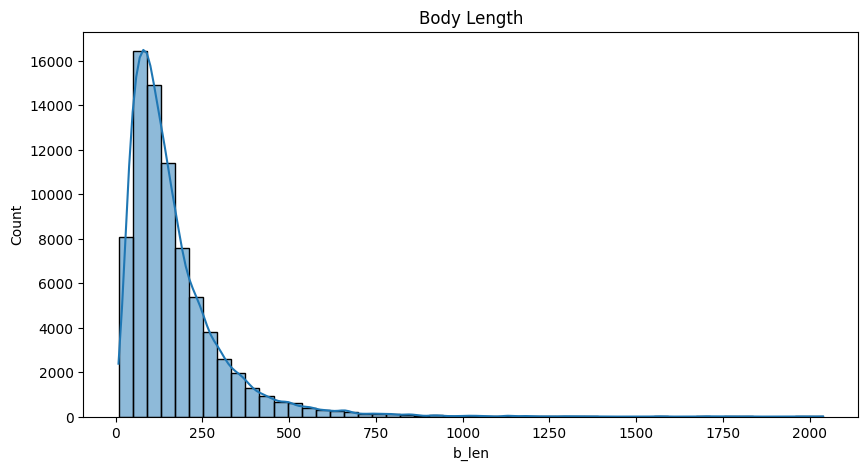

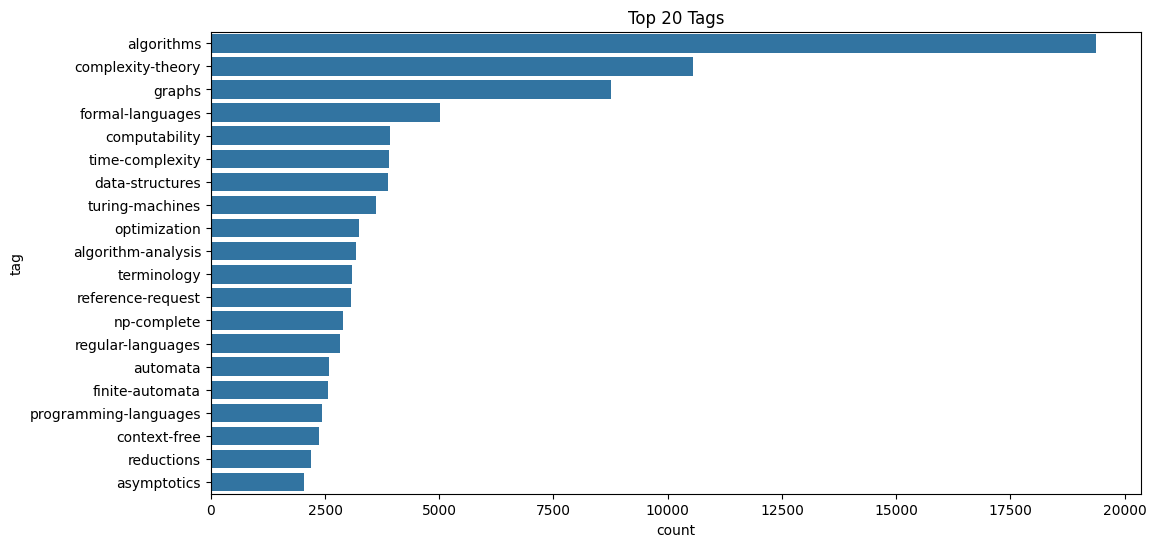

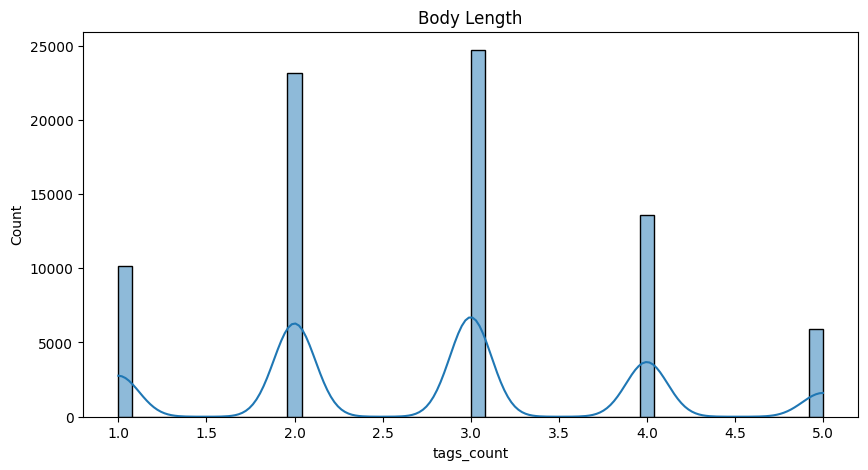

In [18]:
eda(df)

### 2. Correlations, visualizing tags relation

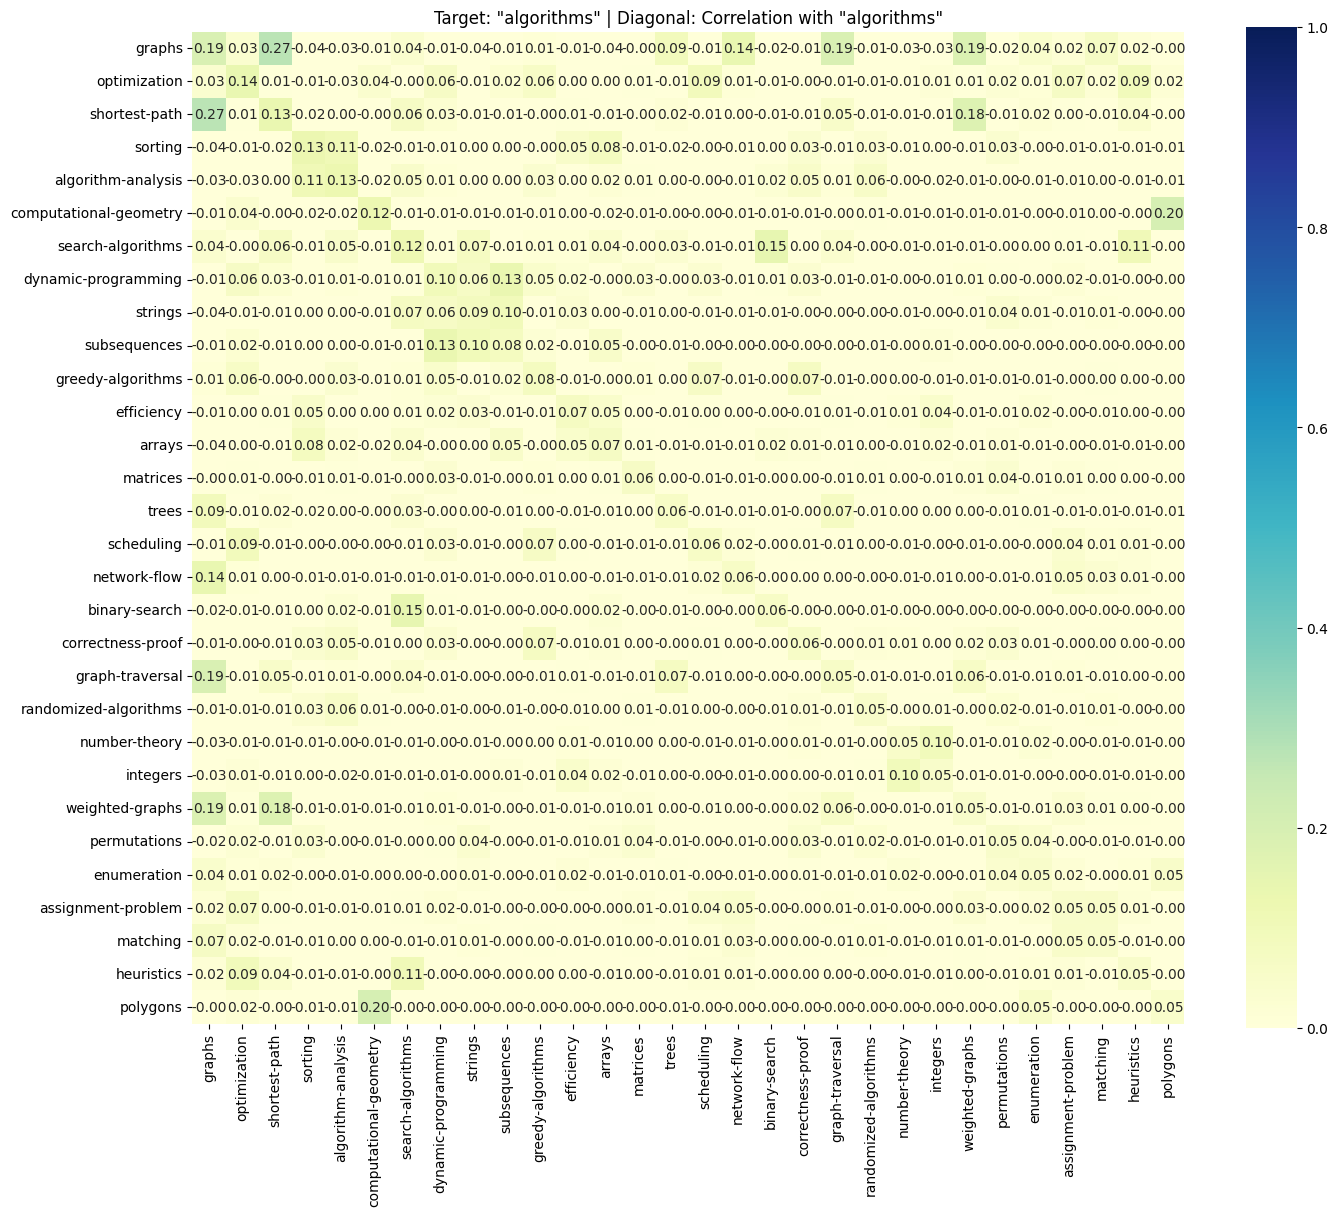

In [ ]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer

def plot_tag(m, u_tags, target = "algorithms", top=30, out='result/cs/cov_matrix.png'):
    if target not in u_tags: return print(f"Tag {target} not found")
    
    v = np.sqrt(np.diag(m))
    v[v == 0] = 1e-9
    corr_m = m / np.outer(v, v)
    
    t2i = {t: i for i, t in enumerate(u_tags)}
    tid = t2i[target]
    
    row = corr_m[tid]
    idx = np.argsort(row)[::-1]
    rel_idx = idx[idx != tid][:top]
    
    sub_m = corr_m[np.ix_(rel_idx, rel_idx)].copy()
    t_sub = [u_tags[i] for i in rel_idx]
    
    for i, idx_val in enumerate(rel_idx):
        sub_m[i, i] = corr_m[idx_val, tid]
        
    plt.figure(figsize=(16, 13))
    sns.heatmap(sub_m, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, 
                xticklabels=t_sub, yticklabels=t_sub, square=True)
    plt.title(f'Target: "{target}" | Diagonal: Correlation with "{target}"')
    plt.savefig(out)
    plt.show()
    plt.close()

def plot_co(cov_m, u_tags, top_n=30, out='result/cs/co_matrix.png'):
    idx = np.argsort(np.diag(cov_m))[::-1][:top_n]
    m_sub = cov_m[np.ix_(idx, idx)]
    t_sub = [u_tags[i] for i in idx]
    
    plt.figure(figsize=(15, 12))
    sns.heatmap(m_sub, annot=False, cmap='RdBu_r', center=0, 
                xticklabels=t_sub, yticklabels=t_sub, square=True)
    plt.title(f'Top {top_n} Tag Covariance Matrix')
    
    os.makedirs(os.path.dirname(out), exist_ok=True)
    plt.savefig(out)
    plt.show()

def get_cov_matrix(df, plot = True):
    tag_lists = df['tags']
    mlb = MultiLabelBinarizer(sparse_output=True)
    X = mlb.fit_transform(tag_lists)
    u_tags = mlb.classes_
    
    n = X.shape[0]

    sum_x = np.array(X.sum(axis=0)).flatten()
    dot_product = (X.T @ X).toarray() 
    
    cov_m = (dot_product / (n - 1)) - np.outer(sum_x, sum_x) / (n * (n - 1))
    if plot:
        plot_tag(cov_m, u_tags)
    return cov_m, u_tags

m, u_tags = get_cov_matrix(df)

### 3. Clustering tags, forming community

In [20]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

def get_subsumption(df, threshold=0.8):
    tag_lists = df['tags']
    mlb = MultiLabelBinarizer(sparse_output=True)
    X = mlb.fit_transform(tag_lists)
    u_tags = mlb.classes_
    
    counts = np.array(X.sum(axis=0)).flatten()
    co_matrix = (X.T @ X).toarray()
    
    prob_matrix = co_matrix / counts
    
    hierarchy = []
    for i, tag_b in enumerate(u_tags):
        for j, tag_a in enumerate(u_tags):
            if i != j and prob_matrix[j, i] >= threshold:
                if prob_matrix[i, j] < prob_matrix[j, i]:
                    hierarchy.append({'child': tag_b, 'parent': tag_a, 'conf': prob_matrix[j, i]})
                    
    return pd.DataFrame(hierarchy), co_matrix, u_tags

def get_communities(co_matrix, u_tags, min_weight=5):
    G = nx.Graph()
    for i in range(len(u_tags)):
        for j in range(i + 1, len(u_tags)):
            if co_matrix[i, j] >= min_weight:
                G.add_edge(u_tags[i], u_tags[j], weight=co_matrix[i, j])
    
    partition = community_louvain.best_partition(G, weight='weight')
    return partition

def analyze_hierarchy(df):
    sub_df, co_m, tags = get_subsumption(df)
    comm_map = get_communities(co_m, tags)
    
    res = []
    for tag in tags:
        res.append({
            'tag': tag,
            'community': comm_map.get(tag, -1),
            'is_root': tag in sub_df['parent'].values,
            'parent_candidate': sub_df[sub_df['child'] == tag]['parent'].tolist()[:3]
        })
        
    roots = sub_df.groupby('parent').size().sort_values(ascending=False)
    return pd.DataFrame(res), roots



In [21]:
res_df, root_stats = analyze_hierarchy(df)
print("--- Root Tags ---")
print(root_stats.head(5))
print("\n--- Sample Hierarchy ---")
print(res_df[res_df['is_root'] == False].head(10))

--- Root Tags ---
parent
algorithms           17
graphs               12
complexity-theory     7
data-structures       7
machine-learning      5
dtype: int64

--- Sample Hierarchy ---
                      tag  community  is_root parent_candidate
0                   2-sat          0    False               []
2           a-star-search          6    False               []
3     abstract-data-types          6    False               []
4          access-control          2    False               []
5        adjacency-matrix          6    False         [graphs]
6               adversary          6    False               []
7                    agda          3    False               []
8   agent-based-computing          4    False               []
9                 algebra          3    False               []
11       algorithm-design          6    False               []


In [22]:
def get_rep_tags(m, u_tags, labels):
    unique_labels = np.unique(labels)
    rep_mapping = {}
    v = np.sqrt(np.diag(m))
    v[v == 0] = 1e-9
    corr_m = m / np.outer(v, v)
    for label in unique_labels:
        idx = np.where(labels == label)[0]
        if len(idx) == 0: continue
        sub_corr = corr_m[np.ix_(idx, idx)]
        centrality = sub_corr.sum(axis=1)
        best_idx = idx[np.argmax(centrality)]
        rep_mapping[label] = u_tags[best_idx]
    return rep_mapping

def analyze_clusters_hybrid(df, min_weight=1):
    sub_df, co_m, u_tags = get_subsumption(df)
    
    G = nx.Graph()
    G.add_nodes_from(u_tags)
    for i in range(len(u_tags)):
        for j in range(i + 1, len(u_tags)):
            if co_m[i, j] >= min_weight:
                G.add_edge(u_tags[i], u_tags[j], weight=co_m[i, j])
    
    partition = community_louvain.best_partition(G, weight='weight')
    
    v = np.sqrt(np.diag(co_m))
    v[v == 0] = 1e-9
    corr_m = co_m / np.outer(v, v)
    
    unique_comms = set(partition.values())
    louvain_rep_map = {}
    for c_id in unique_comms:
        idx = [i for i, t in enumerate(u_tags) if partition.get(t) == c_id]
        if not idx: continue
        sub_corr = corr_m[np.ix_(idx, idx)]
        louvain_rep_map[c_id] = u_tags[idx[np.argmax(sub_corr.sum(axis=1))]]

    cluster_counts = pd.Series(partition.values()).value_counts()
    k_opt = len(cluster_counts[cluster_counts > 1])
    if k_opt < 2: k_opt = 20
        
    dist_m = 1 - np.clip(corr_m, 0, 1)
    ac = AgglomerativeClustering(n_clusters=k_opt, metric='precomputed', linkage='average')
    ac_labels = ac.fit_predict(dist_m)
    
    ac_rep_map = get_rep_tags(co_m, u_tags, ac_labels)
    
    res_list = []
    for i, tag in enumerate(u_tags):
        l_id = partition.get(tag)
        a_id = ac_labels[i]
        res_list.append({
            'tag': tag,
            'ac_id': a_id,
            'ac_name': ac_rep_map.get(a_id),
            'louvain_id': l_id,
            'louvain_name': louvain_rep_map.get(l_id, "Isolated"),
            'is_root': tag in sub_df['parent'].values
        })
        
    res_df = pd.DataFrame(res_list)
    
    summary = res_df.groupby(['louvain_id', 'louvain_name']).size().reset_index(name='tag_count')
    summary = summary.sort_values('tag_count', ascending=False).reset_index(drop=True)
    
    return res_df, summary

In [23]:
res_df, detected_k = analyze_clusters_hybrid(df)

In [24]:
print("--- Cluster Analysis ---")
print(f"Detected Clusters: {detected_k.shape[0]}")
print(detected_k)


--- Cluster Analysis ---
Detected Clusters: 11
    louvain_id           louvain_name  tag_count
0            1             algorithms        215
1            8  programming-languages        121
2            3      operating-systems         95
3            6       machine-learning         72
4            2       formal-languages         69
5            0      complexity-theory         53
6            7            asymptotics          9
7            5             complexity          1
8            4                 career          1
9            9           epistemology          1
10          10           generic-case          1


In [25]:
print(len(res_df[res_df['louvain_name'] == "algorithms"]))
print(len(res_df[res_df['ac_name'] == "algorithms"]))

215
632


## II. Preprocess whole data, put it all togeter

In [ ]:
from typing import Union
import os
import re

def filter_tags(df, ratio=0.001, filter=None):
    N = len(df)
    if ratio:
        threshold = int(N * ratio)
        
        all_tags = [t.strip() for tags in df['tags'] for t in (tags if isinstance(tags, list) else str(tags).split('|'))]
        tag_counts = pd.Series(all_tags).value_counts()
        valid_tags = set(tag_counts[tag_counts >= threshold].index)
        print(f"--- FLAT BASELINE SETUP (Ratio: {ratio}) ---")
        print(f"Calculated Threshold: {threshold} samples")
        print(f"Unique Tags Remaining: {len(valid_tags)} (Dropped {len(tag_counts) - len(valid_tags)})")
        print(f"Samples Maintained: {len(df)} / {N}")
    elif filter is not None:    
        valid_tags = filter
    else:
        df['filtered_tags'] = df['tags']
        all_tags = [t.strip() for tags in df['tags'] for t in (tags if isinstance(tags, list) else str(tags).split('|'))]
        tag_counts = pd.Series(all_tags).value_counts()
        valid_tags = set(tag_counts[tag_counts > 0].index)
        
        return df, sorted(list(valid_tags))
        
    def clean_func(tags):
            t_list = tags if isinstance(tags, list) else str(tags).split('|')
            return [t.strip() for t in t_list if t.strip() in valid_tags]
    
    df['filtered_tags'] = df['tags'].apply(clean_func)
    

    df = df[df['filtered_tags'].map(len) > 0].copy()
    
    
    
    return df, sorted(list(valid_tags))


def clean(text):
    text = re.sub(r'<code>(.*?)</code>', r' [CODE_START] \1 [CODE_END] ', str(text), flags=re.DOTALL)
    text = re.sub(r'<.*?>', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def get_comm(df):
    sub_df, co_m, u_tags = get_subsumption(df)
    partition = get_communities(co_m, u_tags, min_weight=1)
    
    v = np.sqrt(np.diag(co_m))
    v[v == 0] = 1e-9
    corr_m = co_m / np.outer(v, v)
    
    unique_ids = set(partition.values())
    rep_names = {}
    for c_id in unique_ids:
        indices = [i for i, t in enumerate(u_tags) if partition.get(t) == c_id]
        if not indices: continue
        sub_corr = corr_m[np.ix_(indices, indices)]
        centrality = sub_corr.sum(axis=1)
        rep_names[c_id] = u_tags[indices[np.argmax(centrality)]]
        
    return partition, rep_names

def prep(src, dst=None, ratio=0.001, filter = None):
    if isinstance(src, str):
        df = pd.read_csv(src).dropna()
    else:
        df = src.dropna()

    df['text'] = (df['title'] + " " + df['body']).apply(clean)
    if ratio:
        df, val_tags = filter_tags(df, ratio=ratio)
    else:
        df, val_tags = filter_tags(df, ratio=None, filter = filter)
    
    # Get Community Mapping
    mapping, names = get_comm(df)
    
    def map_to_multi_l1(tags):
        l1_ids = {mapping.get(t) for t in tags if mapping.get(t) is not None}
        return sorted(list(l1_ids))

    df['l1'] = df['filtered_tags'].apply(map_to_multi_l1)
    
    df['l1_name'] = df['l1'].apply(lambda ids: [names.get(i) for i in ids])

    if dst:
        if os.path.dirname(dst):
            os.makedirs(os.path.dirname(dst), exist_ok=True)
        df.to_csv(dst, index=False)
        
    return df, mapping, names, val_tags

In [ ]:
df, mapper, names, val_tags = prep(df, 'data/cs/cs_processed.csv')


--- FLAT BASELINE SETUP (Ratio: 0.001) ---
Calculated Threshold: 77 samples
Unique Tags Remaining: 322 (Dropped 316)
Samples Maintained: 77089 / 77500


In [14]:
df.head(3)

,title,body,tags,t_len,b_len,tags_count,text,filtered_tags,l1,l1_name
0,Why is quicksort better than other sorting alg...,<p>In a standard algorithms course we are taug...,"[algorithms, sorting]",10,358,2,Why is quicksort better than other sorting alg...,"[algorithms, sorting]",[1],[algorithms]
1,"What is the definition of P, NP, NP-complete a...",<p>I'm in a course about <em>computing</em> an...,"[complexity-theory, terminology, complexity-cl...",10,61,5,"What is the definition of P, NP, NP-complete a...","[complexity-theory, terminology, complexity-cl...","[0, 4, 6]","[complexity-theory, programming-languages, for..."
2,Why is writing down mathematical proofs more f...,<p>I have noticed that I find it far easier to...,"[correctness-proof, mathematical-foundations, ...",12,602,3,Why is writing down mathematical proofs more f...,"[correctness-proof, mathematical-foundations]","[1, 4]","[algorithms, programming-languages]"


In [15]:
print(mapper)
print(names)

{'2-sat': 0, '3-sat': 0, 'algorithms': 1, 'complexity-theory': 0, 'constraint-programming': 0, 'constraint-satisfaction': 0, 'graphs': 1, 'np-complete': 0, 'np-hard': 0, 'polynomial-time': 0, 'probability-theory': 1, 'random-walks': 1, 'randomized-algorithms': 1, 'satisfiability': 0, 'time-complexity': 0, 'xor': 1, 'approximation': 1, 'asymptotics': 3, 'bayesian-network': 0, 'bipartite-graph': 1, 'boolean-algebra': 4, 'circuits': 0, 'co-np': 0, 'colorings': 1, 'complexity-classes': 0, 'computability': 6, 'computational-complexity': 0, 'decision-problem': 0, 'factoring': 0, 'greedy-algorithms': 1, 'heuristics': 1, 'kolmogorov-complexity': 6, 'logic': 4, 'maxsat': 0, 'normal-forms': 6, 'np': 0, 'optimization': 1, 'p-vs-np': 0, 'parameterized-complexity': 0, 'pedagogy': 5, 'polynomial-time-reductions': 0, 'probabilistic-algorithms': 1, 'proof-techniques': 6, 'quantum-computing': 0, 'reductions': 0, 'reference-request': 4, 'sat-solvers': 0, 'space-complexity': 0, 'subset-sum': 0, 'terminol

In [16]:
for k,v in mapper.items():
    print(f"{k}", end=", ") if v == 5 else None

pedagogy, access-control, concurrency, memory-allocation, operating-systems, security, distributed-systems, parallel-computing, arithmetic, binary-arithmetic, computer-networks, cpu-cache, cryptography, error-estimation, lattices, memory-access, numerical-algorithms, os-kernel, performance, power-consumption, threads, virtual-memory, assembly, authentication, benchmarking, binary, blockchain, byzantine, clocks, communication-protocols, computer-algebra, computer-architecture, consensus, cpu-pipelines, critical-section, database-theory, databases, deadlocks, digital-circuits, encryption, fault-tolerance, floating-point, mapreduce, mathematical-software, memory-management, message-passing, multi-tasking, mutual-exclusion, number-formats, numeral-representations, numerical-analysis, one-way-functions, paging, peer-to-peer, process-scheduling, protocols, resource-allocation, rounding, storage, synchronization, voting, real-time, cpu, memory-hardware, mips, descriptive-complexity, high-perf

In [ ]:
import pandas as pd
import numpy as np

def run_comprehensive_audit(df, mapper):
    results = []
    l3_counts = []
    
    for _, row in df.iterrows():
        assigned = row['l1']
        assigned_set = {assigned} if not isinstance(assigned, (list, set, np.ndarray)) else set(assigned)
        
        raw_tags = row['tags']
        tag_list = raw_tags if isinstance(raw_tags, list) else str(raw_tags).split('|')
        tag_list = [t.strip() for t in tag_list if t.strip()]
        
        actual_l1_from_tags = {mapper.get(t) for t in tag_list if mapper.get(t) is not None}
        
        matches = [mapper.get(t) in assigned_set for t in tag_list if mapper.get(t) is not None]
        num_matches = sum(matches)
        total_valid_tags = len(matches)
        
        l3_counts.append(len(tag_list))
        results.append({
            'n_l3': len(tag_list),
            'n_l1_actual': len(actual_l1_from_tags),
            'is_fully_consistent': num_matches == total_valid_tags if total_valid_tags > 0 else True,
            'mismatch_count': total_valid_tags - num_matches
        })

    res_df = pd.DataFrame(results)
    l3_series = pd.Series(l3_counts)
    l1_actual_series = res_df['n_l1_actual']

    print("--- GLOBAL TAG (L3) STATISTICS ---")
    print(f"Mean L3 per Question: {l3_series.mean():.4f}")
    print(f"Std L3 per Question: {l3_series.std():.4f}")
    print(f"Min/Max L3 per Question: {l3_series.min()} / {l3_series.max()}")

    print("\n--- ACTUAL CLUSTER (L1) DISTRIBUTION (FROM TAGS) ---")
    print(f"Mean L1 per Question: {l1_actual_series.mean():.4f}")
    print(f"Std L1 per Question: {l1_actual_series.std():.4f}")
    print(f"Ratio L1 > 1 (Multi-disciplinary): {(l1_actual_series > 1).mean()*100:.2f}%")
    print(f"Ratio L1 == 0 (Unmapped): {(l1_actual_series == 0).mean()*100:.2f}%")
    print(f"Max L1 clusters in a single Question: {l1_actual_series.max()}")

    print("\n--- HIERARCHY CONSISTENCY ANALYSIS ---")
    print(f"Fully Consistent Questions: {res_df['is_fully_consistent'].mean()*100:.2f}%")
    
    total_mismatches = res_df['mismatch_count'].sum()
    total_tags_processed = l3_series.sum()
    print(f"Total Tags Mismatched with Assigned L1: {total_mismatches}")
    print(f"Tag-level Error Rate: {(total_mismatches / total_tags_processed)*100:.2f}%")

    return res_df

audit_results = run_comprehensive_audit(df, mapper)

--- GLOBAL TAG (L3) STATISTICS ---
Mean L3 per Question: 2.7744
Std L3 per Question: 1.1143
Min/Max L3 per Question: 1 / 5

--- ACTUAL CLUSTER (L1) DISTRIBUTION (FROM TAGS) ---
Mean L1 per Question: 1.4359
Std L1 per Question: 0.6109
Ratio L1 > 1 (Multi-disciplinary): 37.64%
Ratio L1 == 0 (Unmapped): 0.00%
Max L1 clusters in a single Question: 5

--- HIERARCHY CONSISTENCY ANALYSIS ---
Fully Consistent Questions: 97.80%
Total Tags Mismatched with Assigned L1: 1799
Tag-level Error Rate: 0.84%


# Phase 3: Training LSTM

## I. Set up

### 1. Embedding

In [ ]:
import torch
import pandas as pd
from sentence_transformers import SentenceTransformer

class EmbeddingExtractor:
    def __init__(self, model_name='sentence-transformers/all-MiniLM-L6-v2', device=None):
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = SentenceTransformer(model_name).to(self.device)
        self.dim = 384 
        

    def extract(self, df, batch_size=64, save_path=None):
        texts = df['text'].tolist()
        if len(texts) < 5000:
            print(f"Warning: Dataset size ({len(texts)}) is below the assignment requirement.")
        else:
            print(f"Extracting embeddings for {len(texts)} samples...")
        embeddings = self.model.encode(
            texts,
            batch_size=batch_size,
            show_progress_bar=True,
            convert_to_tensor=True,
            device=self.device
        )
        
        if save_path:
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            torch.save(embeddings.cpu(), save_path)
            print(f"Embeddings saved to {save_path}. Dimension: {self.dim}")
            
        return embeddings

    @staticmethod
    def load_embeddings(path = 'data/cs/cs_embeddings.pt'):
        if os.path.exists(path):
            return torch.load(path)
        raise FileNotFoundError(f"No embeddings found at {path}")

extractor = EmbeddingExtractor()
# embeddings = extractor.extract(df, save_path='data/cs/cs_embeddings.pt')
embeddings = extractor.load_embeddings(path='data/cs/cs_embeddings.pt')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 2. LSTM class 
- Inherit from torch.nn library
- Add head manually at will 
- Use Bidirection LSTM for more context coverage

Attention Head: We know that deep neural network suffers from gradient vanishing. Self Attention capture and reenforce gradient of core concepts. 

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class SelfAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(SelfAttention, self).__init__()
        self.projection = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, encoder_outputs):
        energy = self.projection(encoder_outputs)
        weights = F.softmax(energy.squeeze(-1), dim=1)
        outputs = (encoder_outputs * weights.unsqueeze(-1)).sum(dim=1)
        return outputs, weights



Bidirectional LSTM: Using Dual-context Capture, better in getting the semantic of key context, esspecially in our real life dataset, mixing of Nature Language questions and statements

In [ ]:
class BiLSTM(nn.Module):
    def __init__(self, input_dim=384, hidden_dim=128, dropout=0.3):
        super(BiLSTM, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = SelfAttention(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleDict()

    def add_head(self, name, num_classes):
        self.heads[name] = nn.Linear(self.hidden_dim * 2, num_classes)
        return self

    def forward(self, x, head_names=None):
        x = x.float()
        if x.dim() == 2: x = x.unsqueeze(1)
        lstm_out, _ = self.lstm(x)
        context_vector, attn_weights = self.attention(lstm_out)
        context_vector = self.dropout(context_vector)
        
        results = {'attention': attn_weights}
        target_heads = head_names if head_names else self.heads.keys()
        for name in target_heads:
            if name in self.heads:
                results[name] = self.heads[name](context_vector)
        return results
    @staticmethod
    def load_model(path, heads_config, device='cpu', input_dim=384, hidden_dim=128):
        model = BiLSTM(input_dim=input_dim, hidden_dim=hidden_dim)
        
        for name, num_classes in heads_config.items():
            model.add_head(name, num_classes)
            
        checkpoint = torch.load(path, map_location=device)
        state_dict = checkpoint.get('model_state', checkpoint)
        
        try:
            model.load_state_dict(state_dict, strict=True)
            model.to(device)
            model.eval()
            print(f"Successfully loaded weights from {path}")
        except RuntimeError as e:
            print(f"Error: {e}")
            
        return model

            

class MultiLayerDataset(Dataset):
    def __init__(self, embeddings, l1_multihot, l2_labels, l3_multihot):
        self.x = embeddings
        self.y = {
            'l1': torch.tensor(l1_multihot, dtype=torch.float),
            'l2': torch.tensor(l2_labels, dtype=torch.long),
            'l3': torch.tensor(l3_multihot, dtype=torch.float)
        }

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], {name: label[idx] for name, label in self.y.items()}

class MultiTaskLoss(nn.Module):
    def __init__(self, weights=None):
        super(MultiTaskLoss, self).__init__()
        self.weights = weights if weights else {'l1': 0.1, 'l2': 0.3, 'l3': 0.6}
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, predictions, targets):
        total_loss = 0
        loss_dict = {}
        for name, pred in predictions.items():
            if name == 'attention' or name not in targets: continue
            loss = self.bce_loss(pred, targets[name].float())
            w = self.weights.get(name, 1.0)
            total_loss += w * loss
            loss_dict[f'loss_{name}'] = loss.item()
        return total_loss, loss_dict

### 3. Dataload and split

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
import torch
from torch.utils.data import TensorDataset, DataLoader
from skmultilearn.model_selection import IterativeStratification
from sklearn.metrics import f1_score, hamming_loss
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from tqdm import tqdm

#  label encode
mlb = MultiLabelBinarizer()
y_l = mlb.fit_transform(df['filtered_tags'])

if len(y_l) == len(embeddings) and len(embeddings) == len(df):
    print(f"Debug success. Data lenght: {len(y_l)}")

df = df.reset_index(drop=True)
X = embeddings[df.index]
y = torch.tensor(y_l, dtype=torch.float32)

stratifier = IterativeStratification(n_splits=2, order=1, sample_distribution_per_fold=[0.2, 0.8])
train_indices, val_indices = next(stratifier.split(X=df.index.values.reshape(-1, 1), y=y_l))

X_train = torch.tensor(embeddings[train_indices], dtype=torch.float32)
y_train = torch.tensor(y_l[train_indices], dtype=torch.float32)

X_val = torch.tensor(embeddings[val_indices], dtype=torch.float32)
y_val = torch.tensor(y_l[val_indices], dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=128, shuffle=False)

print(f"Sync Success | Train: {len(X_train)} | Val: {len(X_val)} | Classes: {len(mlb.classes_)}")



Debug success. Data lenght: 77089
Sync Success | Train: 61807 | Val: 15282 | Classes: 322


## II. Training

### 1. Init optimizer

In [77]:
import torch.optim as optim
from sklearn.metrics import f1_score, hamming_loss
import numpy as np
from tqdm import tqdm

# Config
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(mlb.classes_)

# Model Init
model = BiLSTM(input_dim=384, hidden_dim=256).add_head('l3', num_classes)
model.to(dev)

# Loss & Optimizer
opt = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
crit = torch.nn.BCEWithLogitsLoss()

### 2. Implement training epoch with tracking bars

In [ ]:
import torch.optim as optim
from sklearn.metrics import f1_score, hamming_loss
import numpy as np
from tqdm import tqdm

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    all_preds, all_targets = [], []
    
    pbar = tqdm(loader, desc="Training Batch", leave=True)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        
        # Forward & Backward
        outputs = model(x, head_names=['l3'])['l3']
        loss = criterion(outputs, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
        preds = (torch.sigmoid(outputs) > 0.5).cpu().detach().numpy()
        all_preds.append(preds)
        all_targets.append(y.cpu().detach().numpy())

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    
    return {
        'loss': epoch_loss / len(loader),
        'f1': f1_score(all_targets, all_preds, average='macro', zero_division=0),
        'hamming': hamming_loss(all_targets, all_preds)
    }

def full_training(model, loader, optimizer, criterion, device, epochs=30, path = 'model/weight/cslstm_attention.pt'): # a training function with simplified status tracking
    print(f"--- Starting Training on {device} ---")
    for epoch in range(epochs):
        metrics = train_epoch(model, loader, optimizer, criterion, device)
        
        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Loss: {metrics['loss']:.4f} | "
              f"Macro-F1: {metrics['f1']:.4f} | "
              f"Hamming: {metrics['hamming']:.4f}")
    

    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")




In [ ]:
# full_training(model, train_loader, opt, crit, dev, epochs=30, path = 'model/weight/cslstm_attention.pt')

--- Starting Training on cuda ---


Training Batch: 100%|██████████| 484/484 [00:04<00:00, 114.45it/s, loss=0.0455]


Epoch 01/30 | Loss: 0.0788 | Macro-F1: 0.0026 | Hamming: 0.0115


Training Batch: 100%|██████████| 484/484 [00:03<00:00, 122.83it/s, loss=0.0233]


Epoch 02/30 | Loss: 0.0351 | Macro-F1: 0.0073 | Hamming: 0.0078


...

Epoch 28/30 | Loss: 0.0103 | Macro-F1: 0.7847 | Hamming: 0.0038


Training Batch: 100%|██████████| 484/484 [00:03<00:00, 131.58it/s, loss=0.0088]


Epoch 29/30 | Loss: 0.0100 | Macro-F1: 0.7967 | Hamming: 0.0037


Training Batch: 100%|██████████| 484/484 [00:03<00:00, 136.28it/s, loss=0.0060]


Epoch 30/30 | Loss: 0.0097 | Macro-F1: 0.8035 | Hamming: 0.0036
Model saved to model/weight/lstm_baseline.pt


### 3. Comprehensive evaluation

#### Classification metrics:
- Accuracy: Exact Match Ratio. Expected to be low since it counts via samples, not tags
- Precision: Show how many predicted labels are actually correct
- Recall: Show how many of the actual correct labels were guessed
- F1-Score: balances the trade-off between missing labels and over-predicting

#### Multilabel metrics:
- Hamming Loss: The ratio of the total number of labels that are incorrectly predicted
- nDCG@k: Normalized Discounted Cumulative Gain, rewarding the correct labels the higher they are on the ranked list.

In [ ]:
from sklearn.metrics import classification_report, hamming_loss, accuracy_score, ndcg_score
from tabulate import tabulate
import pandas as pd
import numpy as np
import os
import torch
from tqdm import tqdm

def eval(model, loader, mlb, device, thres=0.3, active_head='l3', filename="result/cs/report/report.csv"):
    model.eval()
    all_scores, all_targets = [], []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Predicting"):
            if len(batch) == 3:
                ids, mask, y = batch[0].to(device).long(), batch[1].to(device).long(), batch[2].to(device).float()
            else:
                ids, y = batch[0].to(device).float(), batch[1].to(device).float()
                mask = (ids != 0).to(device).long()
            # Additional head for Trans
            if type(model).__name__ == 'Trans': 
                outputs = model(ids, mask, active_head=active_head)[active_head]
            else:
                ids = ids.float()
                out = model(ids)
                outputs = out['l3'] if isinstance(out, dict) else out
            
            scores = torch.sigmoid(outputs).cpu().numpy()
            
            all_scores.append(scores)
            
            all_targets.append(y.cpu().numpy())
            
    y_score = np.vstack(all_scores)
    y_true = np.vstack(all_targets)
    y_pred = (y_score > thres).astype(int)
    
    report_dict = classification_report(y_true, y_pred, target_names=mlb.classes_, output_dict=True, zero_division=0)
    h_loss = hamming_loss(y_true, y_pred)
    sub_acc = accuracy_score(y_true, y_pred)
    ndcg_5 = ndcg_score(y_true, y_score, k=5)
    
    metrics = ['micro avg', 'macro avg', 'weighted avg', 'samples avg']
    table_data = [[m.upper()] + [report_dict[m][k] for k in ['precision', 'recall', 'f1-score', 'support']] for m in metrics]
    
    basic_tab = tabulate(table_data, headers=['GLOBAL METRIC', 'PRECISION', 'RECALL', 'F1-SCORE', 'SUPPORT'], tablefmt='fancy_grid')
    
    additional_metrics = [
        ["Subset Accuracy", f"{sub_acc:.4f}"],
        ["Hamming Loss", f"{h_loss:.4f}"],
        ["nDCG@5 (Ranking)", f"{ndcg_5:.4f}"]
    ]
    extra_tab = tabulate(additional_metrics, tablefmt='fancy_grid')

    df_report = pd.DataFrame(report_dict).transpose()
    df_report.loc['hamming_loss'] = [h_loss] * 3 + [y_true.shape[0]]
    df_report.loc['subset_accuracy'] = [sub_acc] * 3 + [y_true.shape[0]]
    df_report.loc['ndcg_at_5'] = [ndcg_5] * 3 + [y_true.shape[0]]
    
    if filename:
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        df_report.to_csv(filename, index=True, encoding='utf-8-sig')
    
    return df_report, basic_tab, extra_tab

In [ ]:
rep, basic, extra = eval(model, val_loader, mlb, dev, thres=0.3)
print('\n')
print("======================== Fundamental Metric for classification ========================")
print(basic)
print('\n')
print("===================== Addtional Metric for Multilabel classification =====================")
print(extra)

Predicting: 100%|██████████| 120/120 [00:00<00:00, 241.30it/s]




======================== Fundamental Metric for classification ========================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.723605 │ 0.723342 │   0.723473 │     41188 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.809327 │ 0.692047 │   0.721823 │     41188 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.729227 │ 0.723342 │   0.713793 │     41188 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.737942 │ 0.742396 │   0.709807 │     41188 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛


===================== Addtional Metric for Multilabel classification =====================
╒══════════════════╤════════╕
│ Subset Accuracy

## III. Finetune

In [ ]:
# Config
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(mlb.classes_)
my_heads = {'l3': 322}

lstm = BiLSTM.load_model(
    path="model/weight/cs/lstm_attention.pt", 
    heads_config=my_heads, 
    device=dev,      
    input_dim=384, 
    hidden_dim=256      
)

rep, basic, extra = eval(lstm, val_loader, mlb, dev, thres=0.3)
print('\n')
print("======================== Fundamental Metric for classification ========================")
print(basic)
print('\n')
print("===================== Addtional Metric for Multilabel classification =====================")
print(extra)

Successfully loaded weights from model/weight/lstm_attention.pt


Predicting: 100%|██████████| 120/120 [00:00<00:00, 250.77it/s]




======================== Fundamental Metric for classification ========================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.726398 │ 0.726557 │   0.726478 │     41164 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.817118 │ 0.700365 │   0.730309 │     41164 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.732778 │ 0.726557 │   0.717281 │     41164 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.740363 │ 0.74591  │   0.713258 │     41164 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛


===================== Addtional Metric for Multilabel classification =====================
╒══════════════════╤════════╕
│ Subset Accuracy

#### Epoch 31-60

In [ ]:
full_training(model, train_loader, opt, crit, dev, epochs=30, path = 'model/weight/cslstm_attention.pt')

--- Starting Training on cuda ---


Training Batch: 100%|██████████| 483/483 [00:05<00:00, 82.06it/s, loss=0.0404]


Epoch 01/30 | Loss: 0.0787 | Macro-F1: 0.0030 | Hamming: 0.0118


Training Batch: 100%|██████████| 483/483 [00:05<00:00, 85.04it/s, loss=0.0307]


Epoch 02/30 | Loss: 0.0350 | Macro-F1: 0.0075 | Hamming: 0.0078


...

Epoch 28/30 | Loss: 0.0102 | Macro-F1: 0.7869 | Hamming: 0.0038


Training Batch: 100%|██████████| 483/483 [00:06<00:00, 73.41it/s, loss=0.0092]


Epoch 29/30 | Loss: 0.0099 | Macro-F1: 0.7991 | Hamming: 0.0037


Training Batch: 100%|██████████| 483/483 [00:05<00:00, 82.06it/s, loss=0.0094]


Epoch 30/30 | Loss: 0.0096 | Macro-F1: 0.8095 | Hamming: 0.0035
Model saved to model/weight/lstm_attention.pt


In [89]:
rep, basic, extra = eval(lstm, val_loader, mlb, dev, thres=0.3)
print('\n')
print("======================== Fundamental Metric for classification ========================")
print(basic)
print('\n')
print("===================== Addtional Metric for Multilabel classification =====================")
print(extra)

Predicting: 100%|██████████| 120/120 [00:00<00:00, 206.56it/s]




======================== Fundamental Metric for classification ========================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.726398 │ 0.726557 │   0.726478 │     41164 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.817118 │ 0.700365 │   0.730309 │     41164 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.732778 │ 0.726557 │   0.717281 │     41164 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.740363 │ 0.74591  │   0.713258 │     41164 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛


===================== Addtional Metric for Multilabel classification =====================
╒══════════════════╤════════╕
│ Subset Accuracy

# Phase 4: Training Transformer

## I. Set up training

### 1. Attention Heads
XMC (Extreme Multilabel Classification) study proves that transformer models struggle to map the output to a large amount of labels. Traditional methods such as Global Pooling cause lost of information to minority labels, causing Tail Label Vanishing, aka Label Bias (model only optimize popular labels)

To better perform multilabel classification with > 300 classes, we propose label-wise-attention head. Different from self attention which capture semantic relations within itself - text to text semantic within an unit of context (paragraphs, usually), the Label-wise Attention is the Multihead Attention, each head capturing semantic from the text that correlates to the target label (text-label attention block). Those attention head will help the model remains attentive to key features that can relate to a tag, rather than scatter the attention span across a whole long paragraph

Source of references are XR-Transformer, MatchXML and AttentionXML. They are prime candidates for this method (but going through multiphase training since they got > 10k labels). Achieve SOTA in 2021 (AttentionXML), 2022 (XR-Transformer) and 2024 (MatchXML), only arguably exceeded by PRIME in 2025 with Hard Negative Mining method, creating suficient batches of Label-to-Prototype. However, since PRIME uses Triplet Loss, requiring massive training resources and time, I wont apply that for the sake of my computer

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel

class MaxHead(nn.Module):
    def __init__(self, dim, num_labels):
        super().__init__()
        self.fc = nn.Linear(dim, num_labels)

    def forward(self, x):
        x = torch.max(x, dim=1)[0]
        return self.fc(x)

class GlobalAttention(nn.Module):
    def __init__(self, dim, num_labels):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.fc = nn.Linear(dim, num_labels)

    def forward(self, x):
        e = self.proj(x)
        w = F.softmax(e.squeeze(-1), dim=1)
        c = (x * w.unsqueeze(-1)).sum(dim=1)
        return self.fc(c)

class LabelWiseAttention(nn.Module):
    def __init__(self, dim, num_labels):
        super().__init__()
        self.q = nn.Parameter(torch.randn(num_labels, dim))
        self.fc = nn.Linear(dim, 1)

    def forward(self, x):
        q = self.q.to(x.dtype)

        att = torch.matmul(x, q.transpose(0, 1))
        att = F.softmax(att, dim=1)
        out = torch.matmul(att.transpose(1, 2), x)
        return self.fc(out).squeeze(-1)

### 2. Transformer
- Use all-MiniLM-L6-v2 for lightweight. Future improvement with BERT or RoBERTa are on hold, as referenced from previous SOTA

In [7]:
from transformers import AutoModel

class Trans(nn.Module):
    def __init__(self, model_name='sentence-transformers/all-MiniLM-L6-v2', device=None):
        super().__init__()
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        self.transformer = AutoModel.from_pretrained(model_name)
        self.dim = self.transformer.config.hidden_size
        self.heads = nn.ModuleDict()
        self.to(self.device)

    def add_head(self, name, head_type, num_labels):
        if head_type == 'lwa':
            self.heads[name] = LabelWiseAttention(self.dim, num_labels)
        elif head_type == 'global':
            self.heads[name] = GlobalAttention(self.dim, num_labels)
        elif head_type == 'max':
            self.heads[name] = MaxHead(self.dim, num_labels)
        else:
            raise ValueError(f"Head type {head_type} is not supported!")
        self.heads[name].to(self.device)

    def forward(self, input_ids, attention_mask, active_head='l3'):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        lhs = outputs.last_hidden_state
        
        if active_head == 'all':
            return {name: head(lhs) for name, head in self.heads.items()}
        
        return {active_head: self.heads[active_head](lhs)}
    def load_checkpoint(self, path):
     
        checkpoint = torch.load(path, map_location=self.device, weights_only=False)
        
        # Full Customized Dict
        if isinstance(checkpoint, dict) and 'model_state' in checkpoint:
            self.load_state_dict(checkpoint['model_state'])
            thres = checkpoint.get('best_threshold', 0.3)
            f1 = checkpoint.get('f1', checkpoint.get('macro_f1', 0.0))
            print(f"--> [SUCCESS] Loaded Model. Best Threshold: {thres} | Best F1: {f1:.4f}")
            return thres 
            
        # State_dict
        else:
            self.load_state_dict(checkpoint)
            print(f"--> [SUCCESS] Loaded Raw State Dict. Threshold defaults to 0.3")
            return 0.3

### 3. DataLoad

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
import torch
from torch.utils.data import TensorDataset, DataLoader
from skmultilearn.model_selection import IterativeStratification
from sklearn.metrics import f1_score, hamming_loss
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from tqdm import tqdm

df, mapper, names, val_tags = prep(df)

from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')

df = df.reset_index(drop=True)

encoded = tokenizer(
    df['text'].tolist(), 
    padding='max_length', 
    truncation=True, 
    max_length=512, 
    return_tensors='pt'
)

X_ids = encoded['input_ids']
X_mask = encoded['attention_mask']

mlb = MultiLabelBinarizer()
y_raw = mlb.fit_transform(df['filtered_tags'])
y = torch.tensor(y_raw, dtype=torch.float32)

stratifier = IterativeStratification(n_splits=2, order=1, sample_distribution_per_fold=[0.2, 0.8])
train_indices, val_indices = next(stratifier.split(X=df.index.values.reshape(-1, 1), y=y_raw))

train_loader_trans = DataLoader(
    TensorDataset(X_ids[train_indices], X_mask[train_indices], y[train_indices]), 
    batch_size=16, 
    shuffle=True
)

val_loader_trans = DataLoader(
    TensorDataset(X_ids[val_indices], X_mask[val_indices], y[val_indices]), 
    batch_size=16, 
    shuffle=False
)
print("===================================================================")
print(f"Ready: Train {len(train_indices)} | Val {len(val_indices)}")

--- FLAT BASELINE SETUP (Ratio: 0.001) ---
Calculated Threshold: 77 samples
Unique Tags Remaining: 322 (Dropped 311)
Samples Maintained: 77089 / 77089
Ready: Train 61805 | Val 15284


### 4. Training pipeline

In [ ]:
import gc 

def best_thres(model, val_loader, mlb, device, active_head='l3', max_t=0.85):
    model.eval()
    all_probs, all_targets = [], []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Predicting"):
            ids = batch[0].to(device).long()
            mask = batch[1].to(device) if len(batch) == 3 else (ids != 0).to(device).long()
            y = batch[2].cpu().numpy() if len(batch) == 3 else batch[1].cpu().numpy()
            
            outputs = model(ids, mask, active_head=active_head)[active_head]
            all_probs.append(torch.sigmoid(outputs).cpu().numpy().astype(np.float32))
            all_targets.append(y.astype(np.uint8))
            
    y_probs = np.vstack(all_probs)
    y_true = np.vstack(all_targets)
    
    del all_probs, all_targets
    gc.collect() 
    
    best_t, best_f1 = 0.3, 0
    for t in np.round(np.arange(0.1, max_t + 0.05, 0.05), 2):
        y_pred = (y_probs > t).astype(np.uint8)
        ma_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        
        if ma_f1 > best_f1:
            best_f1, best_t = ma_f1, t
        
        del y_pred
        
    gc.collect() 
    
    report = classification_report(y_true, (y_probs > best_t).astype(np.uint8), 
                                   target_names=mlb.classes_, output_dict=True, zero_division=0)
    
    metrics = ['micro avg', 'macro avg', 'weighted avg', 'samples avg']
    table_data = [[m.upper()] + [report[m][k] for k in ['precision', 'recall', 'f1-score', 'support']] for m in metrics]
    basic_tab = tabulate(table_data, headers=['GLOBAL METRIC', 'PRECISION', 'RECALL', 'F1-SCORE', 'SUPPORT'], tablefmt='fancy_grid')
    
    return best_t, basic_tab, best_f1

In [ ]:
import torch, os, gc
from torch.optim import AdamW
from torch.amp import GradScaler, autocast
from tqdm import tqdm

def train_transformer(model, train_loader, val_loader, mlb, device, head_name='l3', epochs=10,weight = 3.0, train_with_wu = True, acc_steps=2, name="trans_lwa"):
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([weight]).to(device))
    scaler = GradScaler()
    best_f1 = 0.0
    warm_up = max(int(epochs/2)+1, 0) if train_with_wu else 0

    max_t = 0.7
    for epoch in range(epochs):
        if epoch < warm_up and train_with_wu:
            for param in model.transformer.parameters():
                param.requires_grad = False
            lr_backbone = 0.0
            lr_head = 1e-3
            desc = f"Warmup {epoch+1}/{warm_up}"
        else:
            for param in model.transformer.parameters():
                param.requires_grad = True
            lr_backbone = 2e-5
            lr_head = 5e-4
            desc = f"Fine-tune {epoch+1-warm_up}/{epochs-warm_up}"

        optimizer = AdamW([
            {'params': model.transformer.parameters(), 'lr': lr_backbone},
            {'params': model.heads[head_name].parameters(), 'lr': lr_head}
        ], weight_decay=0.01)

        model.train()
        optimizer.zero_grad()
        pbar = tqdm(train_loader, desc=desc)
        
        for i, batch in enumerate(pbar):
            if len(batch) == 3:
                ids, mask, y = batch[0].to(device).long(), batch[1].to(device).long(), batch[2].to(device).float()
            else:
                ids, y = batch[0].to(device).long(), batch[1].to(device).float()
                mask = (ids != 0).to(device).long()

            with autocast(device_type='cuda'):
                outputs = model(ids, mask, active_head=head_name)[head_name]
                loss = criterion(outputs, y) / acc_steps
            
            scaler.scale(loss).backward()
            
            if (i + 1) % acc_steps == 0 or (i + 1) == len(train_loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            pbar.set_postfix({'loss': f"{loss.item() * acc_steps:.4f}"})
            del ids, mask, y, outputs, loss

        cur_t, tab, curr_f1 = best_thres(model, val_loader, mlb, device, active_head=head_name)
        print(f"================== Epoch {epoch + 1} with t = {cur_t} ==================")
        print(tab)
        
        if curr_f1 > best_f1:
            best_f1 = curr_f1
            os.makedirs("model/weight/cs", exist_ok=True)
            save_path = f"model/weight/cs{name}_{head_name}_best.pt"
            torch.save({
                'model_state': model.state_dict(),
                'best_threshold': cur_t,
                'macro_f1': best_f1
            }, save_path)
            print(f"--> Saved: {save_path} (F1: {best_f1:.4f})")
        else: print(f"====> This epoch F!: {curr_f1} ")
        torch.cuda.empty_cache()
        gc.collect()

    return model

## II. Model Implementation

### 1. Traditional Transformer 

A commonly used transformer with MaxHead on top of pretrained model to support classification task

#### Base epoch 1-10

In [ ]:
# This code runs fine before but for a reason I have to manually load the checkpoint later
import gc

gc.collect()
torch.cuda.empty_cache()
trans_base = Trans(device=dev)



trans_base.add_head(name='l3', head_type='max', num_labels=len(mlb.classes_))
trans_base = train_transformer(trans_base, train_loader_trans, val_loader_trans, mlb, dev, 
                          epochs=10, 
                          weight = 3.0,
                          name="trans_base")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Warmup 1/5:   9%|▉         | 360/3863 [00:33<05:22, 10.87it/s, loss=0.0913]


KeyboardInterrupt: 

In [ ]:
# Evaluation of our model

trans_base = Trans(device=dev)
trans_base.add_head(name='l3', head_type='max', num_labels=len(mlb.classes_))
trans_base.load_checkpoint(path = "model/weight/cstrans_base_l3_best.pt")
t, final_tab, f1 = best_thres(trans_base, val_loader_trans, mlb, dev, active_head="l3")
print(f"================== Final with t = {t} ==================")
print(final_tab)
print(f"================== Model f1 = {f1} ==================")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--> [SUCCESS] Loaded Model. Best Threshold: 0.7 | Best F1: 0.7411


Predicting: 100%|██████████| 956/956 [00:55<00:00, 17.31it/s]


================== Final with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.732455 │ 0.866422 │   0.793826 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.722557 │ 0.814881 │   0.746263 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.745149 │ 0.866422 │   0.794296 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.760699 │ 0.871838 │   0.78806  │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
================== Model f1 = 0.7462631690978061 ==================


#### LWA Epoch 1-10

In [ ]:
import gc

gc.collect()
torch.cuda.empty_cache()
trans_lwa = Trans(device=dev)



trans_lwa.add_head(name='l3', head_type='lwa', num_labels=len(mlb.classes_))
trans_lwa = train_transformer(trans_lwa, train_loader_trans, val_loader_trans, mlb, dev, 
                          epochs=10, 
                          weight = 3.0,
                          name="trans_lwa")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Predicting: 100%|██████████| 956/956 [01:02<00:00, 15.38it/s]


================== Epoch 1 with t = 0.1 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │   0.050637  │ 0.367284 │  0.0890033 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │   0.0150421 │ 0.102721 │  0.025533  │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │   0.0618911 │ 0.367284 │  0.103663  │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │   0.0694081 │ 0.371306 │  0.104982  │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.0255)


Predicting: 100%|██████████| 956/956 [01:02<00:00, 15.32it/s]


================== Epoch 2 with t = 0.1 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │   0.0736165 │ 0.446926 │  0.126411  │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │   0.0330775 │ 0.12982  │  0.0448352 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │   0.0777653 │ 0.446926 │  0.127114  │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │   0.0869301 │ 0.444586 │  0.135227  │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.0448)


...

================== Epoch 8 with t = 0.5 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.444537 │ 0.701362 │   0.544169 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.279627 │ 0.402751 │   0.304805 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.427739 │ 0.701362 │   0.51799  │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.476935 │ 0.717805 │   0.540392 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.3048)


Predicting: 100%|██████████| 956/956 [00:57<00:00, 16.66it/s]


================== Epoch 9 with t = 0.55 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.478237 │ 0.729422 │   0.577707 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.341294 │ 0.46449  │   0.362907 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.471557 │ 0.729422 │   0.557757 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.51223  │ 0.746673 │   0.575276 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.3629)


Predicting: 100%|██████████| 956/956 [00:59<00:00, 16.02it/s]


================== Epoch 10 with t = 0.65 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.523068 │ 0.754594 │   0.617854 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.434598 │ 0.559571 │   0.451692 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.533371 │ 0.754594 │   0.608749 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.557982 │ 0.772676 │   0.615894 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.4517)


## III. Deeper Finetuning

LWA not output only 1 vector like Global Pooling or Max Head, but output n vectors with n = amount of tags (432 in our case). It requires deep training for the LWA to capture semantics of all tags, ultlizing output vectors

Upon viewing previous training results, we load the model to continue 5 more epochs for the model to further understand 432 labels

Though I train with warm-up (necessary with first train), it might be a good idea to turn it of since:
1. At warm-up, learning rate of head is fast, which may make them forget the information gained from last training
2. Fine tuning backnone is much slower, turning off warm up may converge it faster to optimal point

If you see the performance lower, that means LWA is either:
1. Forgetting valuable info, or .....
2. Overfit (When that comes the training breaks when you unfreeze the backbone)
Upon that, stop training and change train_with_wu to False

### 1. LWA_Transformer

#### LWA epoch 11-15

In [ ]:
import gc

gc.collect()
torch.cuda.empty_cache()
trans_lwa = Trans(device=dev)



trans_lwa.add_head(name='l3', head_type='lwa', num_labels=len(mlb.classes_))
trans_lwa.load_checkpoint(path = "model/weight/cstrans_lwa_l3_best.pt")

In [ ]:

trans_lwa = train_transformer(trans_lwa, train_loader_trans, val_loader_trans, mlb, dev, 
                          epochs=5, 
                          weight = 3.0,
                          train_witach_wu=True, # I personally dont want to finetune to much an already well trainied model, but turning it off might be a better idea
                          name="trans_lwa")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--> [SUCCESS] Loaded Model. Best Threshold: 0.65 | Best F1: 0.4517


Predicting: 100%|██████████| 956/956 [00:57<00:00, 16.50it/s]


================== Epoch 1 with t = 0.65 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.536128 │ 0.768697 │   0.631686 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.456279 │ 0.589343 │   0.484616 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.541837 │ 0.768697 │   0.622582 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.570876 │ 0.784744 │   0.628748 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.4846)


...

================== Epoch 3 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.564703 │ 0.760541 │   0.648152 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.493751 │ 0.606433 │   0.514285 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.569921 │ 0.760541 │   0.639576 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.599682 │ 0.779425 │   0.645412 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.5143)


Predicting: 100%|██████████| 956/956 [00:59<00:00, 16.17it/s]


================== Epoch 4 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.567855 │ 0.785227 │   0.659081 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.52095  │ 0.671615 │   0.552994 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.58605  │ 0.785227 │   0.658154 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.60455  │ 0.804054 │   0.657988 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.5530)


Predicting: 100%|██████████| 956/956 [01:01<00:00, 15.59it/s]


================== Epoch 5 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.576561 │ 0.838678 │   0.683346 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.555418 │ 0.758159 │   0.613    │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.598274 │ 0.838678 │   0.688297 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.611571 │ 0.852434 │   0.682437 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.6130)


#### LWA Epoch 16-20

In [70]:
trans_lwa = train_transformer(trans_lwa, train_loader_trans, val_loader_trans, mlb, dev, 
                          epochs=5, 
                          weight = 3.0,
                          train_with_wu=False, # Lets try both to see what happens
                          name="trans_lwa")

Predicting: 100%|██████████| 956/956 [01:00<00:00, 15.90it/s]


================== Epoch 1 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.601889 │ 0.863    │   0.709174 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.584325 │ 0.7938   │   0.654497 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.621572 │ 0.863    │   0.71461  │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.638663 │ 0.874022 │   0.710043 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.6545)


Predicting: 100%|██████████| 956/956 [00:59<00:00, 15.99it/s]


================== Epoch 2 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.636913 │ 0.869821 │   0.735366 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.626405 │ 0.812733 │   0.688085 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.654417 │ 0.869821 │   0.739982 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.671058 │ 0.878545 │   0.733949 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.6881)


Predicting: 100%|██████████| 956/956 [00:58<00:00, 16.26it/s]


================== Epoch 3 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.658352 │ 0.896303 │   0.759118 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.648786 │ 0.856937 │   0.722849 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.676625 │ 0.896303 │   0.765179 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.69243  │ 0.903232 │   0.757944 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.7228)


Predicting: 100%|██████████| 956/956 [01:02<00:00, 15.29it/s]


================== Epoch 4 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.660105 │ 0.921378 │   0.769159 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.652913 │ 0.878204 │   0.732961 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.679145 │ 0.921378 │   0.776067 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.696508 │ 0.925224 │   0.77051  │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.7330)


Predicting: 100%|██████████| 956/956 [00:59<00:00, 15.98it/s]


================== Epoch 5 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.681258 │ 0.92934  │   0.786192 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.670946 │ 0.89287  │   0.751927 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.704292 │ 0.92934  │   0.795225 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.717263 │ 0.931017 │   0.787508 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.7519)


#### LWA Epoch 20-25

In [71]:
trans_lwa = train_transformer(trans_lwa, train_loader_trans, val_loader_trans, mlb, dev, 
                          epochs=5, 
                          weight = 3.0,
                          train_with_wu=False, 
                          name="trans_lwa")

Predicting: 100%|██████████| 956/956 [00:59<00:00, 16.02it/s]


================== Epoch 1 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.706469 │ 0.9365   │   0.805382 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.704664 │ 0.899804 │   0.777763 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.722934 │ 0.9365   │   0.81104  │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.741008 │ 0.937753 │   0.806615 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.7778)


Predicting: 100%|██████████| 956/956 [00:59<00:00, 15.99it/s]


================== Epoch 2 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.715879 │ 0.942787 │   0.813812 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.720032 │ 0.905646 │   0.786535 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.732399 │ 0.942787 │   0.819036 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.750264 │ 0.942329 │   0.814164 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.7865)


Predicting: 100%|██████████| 956/956 [00:59<00:00, 16.16it/s]


================== Epoch 3 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.719763 │ 0.948758 │   0.818546 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.707148 │ 0.913767 │   0.782235 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.740948 │ 0.948758 │   0.826511 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.757413 │ 0.948711 │   0.822253 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛


Predicting: 100%|██████████| 956/956 [00:57<00:00, 16.49it/s]


================== Epoch 4 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.73495  │ 0.950992 │   0.829129 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.710784 │ 0.912918 │   0.78485  │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.755121 │ 0.950992 │   0.836461 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.772061 │ 0.950112 │   0.832111 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛


Predicting: 100%|██████████| 956/956 [00:57<00:00, 16.52it/s]


================== Epoch 5 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.762668 │ 0.952812 │   0.847202 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.752182 │ 0.916016 │   0.812084 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.782878 │ 0.952812 │   0.854344 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.795392 │ 0.950165 │   0.84795  │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.8121)


#### LWA Epoch 25-40: Here we speed up learning rate of our Attention Head, since the Loss is too low for the model to learn fast (We should have done it from beginning)

In [91]:
trans_lwa = train_transformer(trans_lwa, train_loader_trans, val_loader_trans, mlb, dev, 
                          epochs=25, 
                          weight = 3.0,
                          train_with_wu=False, 
                          name="trans_lwa")

Predicting: 100%|██████████| 956/956 [00:58<00:00, 16.27it/s]


================== Epoch 1 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.783687 │ 0.958298 │   0.862241 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.776556 │ 0.924621 │   0.830879 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.799818 │ 0.958298 │   0.867534 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.816352 │ 0.956571 │   0.863782 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.8309)


Predicting: 100%|██████████| 956/956 [00:58<00:00, 16.23it/s]


================== Epoch 2 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.797762 │ 0.962109 │   0.872262 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.799651 │ 0.926363 │   0.846689 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.812353 │ 0.962109 │   0.876556 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.826948 │ 0.958963 │   0.872125 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_lwa_l3_best.pt (F1: 0.8467)


Predicting: 100%|██████████| 956/956 [00:59<00:00, 15.95it/s]


...

================== Epoch 23 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.923921 │ 0.975144 │   0.948841 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.915096 │ 0.945182 │   0.923248 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.928421 │ 0.975144 │   0.949601 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.934892 │ 0.97169  │   0.94659  │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
====> This epoch F!: 0.9232482066294689 


Predicting: 100%|██████████| 956/956 [00:59<00:00, 16.02it/s]


================== Epoch 24 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.93426  │ 0.973493 │   0.953473 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.932012 │ 0.945229 │   0.930884 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.940288 │ 0.973493 │   0.954686 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.941312 │ 0.969978 │   0.949259 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
====> This epoch F!: 0.9308836692712772 


Predicting: 100%|██████████| 956/956 [00:58<00:00, 16.45it/s]


================== Epoch 25 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.919292 │ 0.975168 │   0.946406 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.922031 │ 0.94864  │   0.927156 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.92894  │ 0.975168 │   0.948736 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.931563 │ 0.971023 │   0.944241 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
====> This epoch F!: 0.9271559893071821 


### 2. Base_Transformer

In [ ]:
import gc

gc.collect()
torch.cuda.empty_cache()
trans_base = Trans(device=dev)



trans_base.add_head(name='l3', head_type='max', num_labels=len(mlb.classes_))
trans_base.load_checkpoint(path = "model/weight/cstrans_base_l3_best.pt")

#### Base Epoch 10-20

In [72]:
trans_base = train_transformer(trans_base, train_loader_trans, val_loader_trans, mlb, dev, 
                          epochs=10, 
                          weight = 3.0,
                          train_with_wu=False, # This model head nees no deep training
                          name="trans_base")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--> [SUCCESS] Loaded Model. Best Threshold: 0.7 | Best F1: 0.7411


Predicting: 100%|██████████| 956/956 [00:55<00:00, 17.10it/s]


================== Epoch 1 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.739249 │ 0.912591 │   0.816825 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.730054 │ 0.872071 │   0.778121 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.752877 │ 0.912591 │   0.819595 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.773149 │ 0.915088 │   0.817266 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_base_l3_best.pt (F1: 0.7781)


...

================== Epoch 8 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.850228 │ 0.975605 │   0.908612 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.812168 │ 0.951006 │   0.8662   │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.861875 │ 0.975605 │   0.91203  │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.877273 │ 0.972563 │   0.910615 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_base_l3_best.pt (F1: 0.8662)


Predicting: 100%|██████████| 956/956 [00:56<00:00, 16.90it/s]


================== Epoch 9 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.861691 │ 0.974974 │   0.914839 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.819096 │ 0.950635 │   0.871542 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.872121 │ 0.974974 │   0.917909 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.887286 │ 0.971853 │   0.91642  │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_base_l3_best.pt (F1: 0.8715)


Predicting: 100%|██████████| 956/956 [01:00<00:00, 15.93it/s]


================== Epoch 10 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.872079 │ 0.975678 │   0.920974 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.836349 │ 0.947394 │   0.880477 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.881407 │ 0.975678 │   0.923535 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.896226 │ 0.972858 │   0.922428 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_base_l3_best.pt (F1: 0.8805)


#### Base Epoch 20-30

In [73]:
trans_base = train_transformer(trans_base, train_loader_trans, val_loader_trans, mlb, dev, 
                          epochs=10, 
                          weight = 3.0,
                          train_with_wu=False, # This model head nees no deep training
                          name="trans_base")

Predicting: 100%|██████████| 956/956 [00:58<00:00, 16.27it/s]


================== Epoch 1 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.886545 │ 0.976455 │   0.92933  │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.8527   │ 0.951629 │   0.892269 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.894621 │ 0.976455 │   0.931528 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.907818 │ 0.973578 │   0.929857 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_base_l3_best.pt (F1: 0.8923)


Predicting: 100%|██████████| 956/956 [00:57<00:00, 16.62it/s]


================== Epoch 2 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.883608 │ 0.976479 │   0.927725 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.866224 │ 0.952046 │   0.898965 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.89268  │ 0.976479 │   0.930116 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.905172 │ 0.973539 │   0.928269 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_base_l3_best.pt (F1: 0.8990)


Predicting: 100%|██████████| 956/956 [00:56<00:00, 16.82it/s]


...

================== Epoch 8 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.918462 │ 0.975848 │   0.946286 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.890929 │ 0.953019 │   0.912735 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.924607 │ 0.975848 │   0.947618 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.930768 │ 0.972639 │   0.94391  │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛


Predicting: 100%|██████████| 956/956 [00:57<00:00, 16.50it/s]


================== Epoch 9 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.925997 │ 0.97711  │   0.950867 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.907056 │ 0.952962 │   0.923465 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.93136  │ 0.97711  │   0.952039 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.936999 │ 0.974243 │   0.948423 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_base_l3_best.pt (F1: 0.9235)


Predicting: 100%|██████████| 956/956 [00:57<00:00, 16.48it/s]


================== Epoch 10 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.923066 │ 0.977693 │   0.949594 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.900578 │ 0.954511 │   0.919748 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.928518 │ 0.977693 │   0.950697 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.935563 │ 0.975    │   0.94791  │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛


#### Base Epoch 30-40: feels a little extra but we need to train both equal epoch to make comparison

In [92]:
trans_base = train_transformer(trans_base, train_loader_trans, val_loader_trans, mlb, dev, 
                          epochs=10, 
                          weight = 3.0,
                          train_with_wu=False, # This model head nees no deep training
                          name="trans_base")

Predicting: 100%|██████████| 956/956 [00:56<00:00, 16.78it/s]


================== Epoch 1 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.925029 │ 0.976964 │   0.950287 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.907787 │ 0.949095 │   0.920311 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.930922 │ 0.976964 │   0.95151  │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.936523 │ 0.974587 │   0.947968 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_base_l3_best.pt (F1: 0.9203)


Predicting: 100%|██████████| 956/956 [00:56<00:00, 16.82it/s]


================== Epoch 2 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.921802 │ 0.977159 │   0.948673 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.899977 │ 0.950476 │   0.91791  │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.92797  │ 0.977159 │   0.950044 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.933596 │ 0.97397  │   0.946189 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
====> This epoch F!: 0.9179104000742152 


Predicting: 100%|██████████| 956/956 [00:56<00:00, 16.81it/s]


...

================== Epoch 8 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.937103 │ 0.976455 │   0.956374 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.92518  │ 0.949248 │   0.930496 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.940989 │ 0.976455 │   0.956874 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.944572 │ 0.972936 │   0.95287  │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/trans_base_l3_best.pt (F1: 0.9305)


Predicting: 100%|██████████| 956/956 [00:57<00:00, 16.77it/s]


================== Epoch 9 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.933319 │ 0.977474 │   0.954887 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.9196   │ 0.952053 │   0.929191 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.937606 │ 0.977474 │   0.95551  │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.941811 │ 0.974419 │   0.951422 │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
====> This epoch F!: 0.9291910315731648 


Predicting: 100%|██████████| 956/956 [00:56<00:00, 16.80it/s]


================== Epoch 10 with t = 0.7 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.923692 │ 0.978154 │   0.950143 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.896761 │ 0.956082 │   0.919087 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.93005  │ 0.978154 │   0.951678 │     41197 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.93527  │ 0.975248 │   0.94764  │     41197 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
====> This epoch F!: 0.9190869330849858 


### Check Var: Crawl more data for testing

In [ ]:
var_df = fetch_cs_data(target_count=200000,csv_path =  'data/cs/cs_var.csv' )

Progress: 500/200000 (Page 1)
Progress: 1000/200000 (Page 2)
Progress: 1500/200000 (Page 3)
Progress: 2000/200000 (Page 4)
Progress: 2500/200000 (Page 5)
Progress: 3000/200000 (Page 6)
Progress: 3500/200000 (Page 7)
Progress: 4000/200000 (Page 8)
Progress: 4500/200000 (Page 9)
Progress: 5000/200000 (Page 10)
Progress: 5500/200000 (Page 11)
Progress: 6000/200000 (Page 12)
Progress: 6500/200000 (Page 13)
Progress: 7000/200000 (Page 14)
Progress: 7500/200000 (Page 15)
Progress: 8000/200000 (Page 16)
Progress: 8500/200000 (Page 17)
Progress: 9000/200000 (Page 18)
Progress: 9500/200000 (Page 19)
Progress: 10000/200000 (Page 20)
Progress: 10500/200000 (Page 21)
Progress: 11000/200000 (Page 22)
Progress: 11500/200000 (Page 23)
Progress: 12000/200000 (Page 24)
Progress: 12500/200000 (Page 25)
Progress: 13000/200000 (Page 26)
Progress: 13500/200000 (Page 27)
Progress: 14000/200000 (Page 28)
Progress: 14500/200000 (Page 29)
Progress: 15000/200000 (Page 30)
Progress: 15500/200000 (Page 31)
Progre

In [ ]:
import joblib
old_labels = val_tags
var_df, mapper, names, target_labels = prep(src = var_df,dst = "data/cs/cs_var_processed", ratio=None, filter=old_labels )
print(mlb.classes_)
mlb_new = MultiLabelBinarizer(classes=target_labels)
mlb_new.fit([target_labels]) 


['2-sat' '3-sat' 'algorithm-analysis' 'algorithm-design' 'algorithms'
 'ambiguity' 'amortized-analysis' 'applied-theory' 'approximation'
 'arithmetic' 'arrays' 'artificial-intelligence' 'assignment-problem'
 'asymptotics' 'automata' 'automated-theorem-proving' 'average-case'
 'backtracking' 'balanced-search-trees' 'big-o-notation' 'binary'
 'binary-arithmetic' 'binary-search' 'binary-search-trees' 'binary-trees'
 'bipartite-matching' 'bloom-filters' 'board-games' 'books'
 'boolean-algebra' 'c' 'category-theory' 'cellular-automata'
 'check-my-answer' 'check-my-proof' 'chomsky-hierarchy'
 'church-turing-thesis' 'circuits' 'classification' 'clique' 'clocks'
 'closure-properties' 'clustering' 'coding-theory' 'colorings'
 'combinatorics' 'combinatory-logic' 'communication-complexity'
 'communication-protocols' 'comparison' 'compilers' 'complexity-classes'
 'complexity-theory' 'computability' 'computation-models'
 'computational-geometry' 'computer-algebra' 'computer-architecture'
 'computer

In [ ]:
joblib.dump(mlb, 'data/cs/mlb.pkl')

['data/mlb.pkl']

In [ ]:
y = mlb.transform(df['filtered_tags'])
stratifier = IterativeStratification(n_splits=2, order=1, sample_distribution_per_fold=[0.2, 0.8])
train_idx, val_idx = next(stratifier.split(df.index.values.reshape(-1, 1), y))

train_df = df.iloc[train_idx]
val_df = df.iloc[val_idx]

train_df.to_csv('data/cs/cs_var_train.csv', index=False)
val_df.to_csv('data/cs/cs_var_val.csv', index=False)

In [ ]:
import pandas as pd
import joblib
import torch
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer
import ast


mlb = joblib.load('data/cs/mlb.pkl')
print(f"Loaded MLB with {len(mlb.classes_)} classes.")

train_df = pd.read_csv('data/cs/cs_var_train.csv')
val_df = pd.read_csv('data/cs/cs_var_val.csv')

tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')

def prepare_transformer_loader(df, mlb, tokenizer, batch_size=16, shuffle=False):
    if isinstance(df['filtered_tags'].iloc[0], str):
        print("Phát hiện dữ liệu dạng string, đang convert sang list...")
        tags_list = df['filtered_tags'].apply(ast.literal_eval).tolist()
    else:
        tags_list = df['filtered_tags'].tolist()
    y = torch.tensor(mlb.transform(tags_list), dtype=torch.float32)
    
    encoded = tokenizer(
        df['text'].fillna("").tolist(), # Xử lý trường hợp text bị rỗng
        padding='max_length', 
        truncation=True, 
        max_length=512, 
        return_tensors='pt'
    )
    
    dataset = TensorDataset(
        encoded['input_ids'], 
        encoded['attention_mask'], 
        y
    )
    
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

new_train = prepare_transformer_loader(train_df, mlb, tokenizer, batch_size=16, shuffle=True)
new_val = prepare_transformer_loader(val_df, mlb, tokenizer, batch_size=16, shuffle=False)

print("===================================================================")
print(f"Ready for Trans: Train {len(train_df)} | Val {len(val_df)}")

Loaded MLB with 322 classes.
Phát hiện dữ liệu dạng string, đang convert sang list...
Phát hiện dữ liệu dạng string, đang convert sang list...
Ready for Trans: Train 141356 | Val 34869


In [ ]:
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
trans_lwa = Trans(device=dev)
trans_lwa.add_head(name='l3', head_type='lwa', num_labels=len(mlb.classes_))
trans_lwa.load_checkpoint(path = "model/weight/cstrans_lwa_l3_best.pt")

rep_var, basic_var, extra_var = eval(trans_lwa, new_val, mlb, dev,filename = "result/cs/report/check_var.csv", thres= 0.7)
print('\n')
print("======================== Fundamental Metric for classification ========================")
print(basic_var)
print('\n')
print("===================== Addtional Metric for Multilabel classification =====================")
print(extra_var)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--> [SUCCESS] Loaded Model. Best Threshold: 0.7 | Best F1: 0.9359


Predicting: 100%|██████████| 2180/2180 [02:39<00:00, 13.67it/s]




======================== Fundamental Metric for classification ========================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.918718 │ 0.963058 │   0.940366 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.930369 │ 0.926309 │   0.923443 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.922525 │ 0.963058 │   0.939998 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.917926 │ 0.946139 │   0.925452 │     89736 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛


===================== Addtional Metric for Multilabel classification =====================
╒══════════════════╤════════╕
│ Subset Accuracy

In [ ]:
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
trans_base = Trans(device=dev)
trans_base.add_head(name='l3', head_type='max', num_labels=len(mlb.classes_))
trans_base.load_checkpoint(path = "model/weight/cstrans_base_l3_best.pt")

rep_var, basic_var, extra_var = eval(trans_base, new_val, mlb, dev,filename = "result/cs/report/check_var.csv", thres= 0.7)
print('\n')
print("======================== Fundamental Metric for classification ========================")
print(basic_var)
print('\n')
print("===================== Addtional Metric for Multilabel classification =====================")
print(extra_var)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--> [SUCCESS] Loaded Model. Best Threshold: 0.7 | Best F1: 0.9305


Predicting: 100%|██████████| 2180/2180 [02:09<00:00, 16.84it/s]




======================== Fundamental Metric for classification ========================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.915504 │ 0.965332 │   0.939758 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.918529 │ 0.93311  │   0.921787 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.91836  │ 0.965332 │   0.939381 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.91764  │ 0.948511 │   0.925789 │     89736 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛


===================== Addtional Metric for Multilabel classification =====================
╒══════════════════╤════════╕
│ Subset Accuracy